##**Vision Transformer**

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

##Cuda

In [ ]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

##Patch Embedding

In [ ]:
import math

class PatchEmbedding(nn.Module):
  def __init__(self, img_channel, patch_size, d_model):
    super().__init__()

    self.C = img_channel
    self.patch_size = patch_size

    self.Embedding = nn.Linear(patch_size**2 * img_channel, d_model)

  def forward(self, x):
    # (B,C,H,W)
    B,C,H,W = x.shape
    P = self.patch_size
    N = (H*W)//(P**2)

    out = x.new_zeros(B,N,P**2 * C) # same device with x
    idx=0
    for i in range(0, H, P):
      for j in range(0, W, P):
        out[:,idx,:] = x[:,:,i:i+P,j:j+P].reshape(B,-1)
        idx+=1
    out = self.Embedding(out) # (B,N,d_model)

    return out


##Multihead Self Attention

In [ ]:
import math

class MultiheadSelfAttention(nn.Module):
  def __init__(self, d_model, num_heads):
    super().__init__()

    d_k = d_model // num_heads

    self.d_model = d_model
    self.d_k = d_k
    self.num_heads = num_heads

    self.W_Q = nn.Linear(d_model,d_model)
    self.W_K = nn.Linear(d_model,d_model)
    self.W_V = nn.Linear(d_model,d_model)
    self.W_O = nn.Linear(d_model,d_model)

  def forward(self,q,k,v,mask=None):
    batch_size = q.size(0)

    # q,k,v -> Q,K,V
    Q = self.W_Q(q)
    K = self.W_K(k)
    V = self.W_V(v)

    # Multi head
    Q = Q.reshape(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)
    K = K.reshape(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)
    V = V.reshape(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)

    # Attention
    attn_score = torch.matmul(Q, K.transpose(-1,-2)) / math.sqrt(self.d_k)
    if mask is not None:
      attn_score = torch.masked_fill(attn_score, mask==0, -1e9) # mask = [1, 1, 1, ... 0, 0, 0]
    attn_score = torch.softmax(attn_score, dim=-1)
    out = torch.matmul(attn_score, V)

    # Concatenate
    out = out.transpose(1,2).reshape(batch_size,-1,self.d_model)
    out = self.W_O(out)

    return out

##Multi Layer Perceptron

In [ ]:
class MultiLayerPerceptron(nn.Module):
  def __init__(self, d_model, d_ff):
    super().__init__()

    self.Sequential = nn.Sequential(
        nn.Linear(d_model, d_ff),
        nn.GELU(),
        nn.Linear(d_ff,d_model)
    )

  def forward(self,x):
    x = self.Sequential(x)
    return x

##Encoder Block

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, drop_out=0.1):
    super().__init__()

    self.MultiheadSelfAttn = MultiheadSelfAttention(d_model, num_heads)
    self.MLP = MultiLayerPerceptron(d_model, d_ff)

    self.LayerNorm1 = nn.LayerNorm(d_model)
    self.LayerNorm2 = nn.LayerNorm(d_model)

    self.Dropout = nn.Dropout(drop_out)

  def forward(self,x):
    x_LN1 = self.LayerNorm1(x)
    x = self.MultiheadSelfAttn(x_LN1, x_LN1, x_LN1, mask = None) + x

    x_LN2 = self.LayerNorm2(x)
    x = self.MLP(x_LN2) + x

    return x

##Encoder

In [ ]:
class Encoder(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, drop_out=0.1, L=12):
      super().__init__()

      self.L = L
      self.EncBlcockList = nn.ModuleList([
          EncoderBlock(d_model, num_heads, d_ff, drop_out)
          for i in range(L)
      ])

  def forward(self,x):
    for EncBlock in self.EncBlcockList:
      x = EncBlock(x)

    return x

##Vision Transformer

In [ ]:
import math

class VisionTransformer(nn.Module):
  def __init__(self, pt_img_size, img_channel, pt_num_classes, ft_num_classes, patch_size, d_model, num_heads, d_ff, drop_out, L):
    super().__init__()

    self.PatchEmbedding = PatchEmbedding(img_channel, patch_size, d_model)

    self.x_cls = nn.Parameter(torch.randn(1,1,d_model) * math.sqrt(2.0 / d_model)) # He init

    pt_N = pt_img_size**2 // patch_size**2
    self.pt_PositionalEncoding = nn.Parameter(torch.randn(1,pt_N+1, d_model) * math.sqrt(2.0 / d_model)) # He init

    self.Encoder = Encoder(d_model, num_heads, d_ff, drop_out, L)

    self.pt_MLPHead = nn.Linear(d_model, pt_num_classes)
    self.ft_MLPHead = nn.Linear(d_model, ft_num_classes)


  def forward(self, x):
    B = x.size(0)

    x = self.PatchEmbedding(x) # (B,N,d_model)
    x = torch.cat((self.x_cls.expand(B,1,-1),x), dim=1) # (B,N+1,d_model)
    x = self.pt_PositionalEncoding + x

    x = self.Encoder(x)

    x = x[:,0,:]
    x = self.pt_MLPHead(x)

    return x

##CIFAR10

In [ ]:
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2
from torch.utils.data import Dataset,DataLoader

#CIFAR10 download mirror server
CIFAR10.url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"

train_transform = v2.Compose([
    #data augmentation
    v2.RandomCrop(32,padding=4),
    v2.RandomHorizontalFlip(),
    v2.ColorJitter(0.4,0.4,0.4,0.1), #Brightness, ...
    v2.RandomGrayscale(0.2), #RGB -> Gray
    v2.ToTensor()
])

test_transform = v2.Compose([
    v2.ToTensor()
])

train_dataset = CIFAR10(
    root = './data',
    train = True,
    transform= train_transform,
    download = True
)

test_dataset = CIFAR10(
    root = './data',
    train = False,
    transform= test_transform,
    download = True
)

In [ ]:
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2

train_transform = v2.Compose([
    v2.RandomCrop(32,padding=4),
    v2.RandomHorizontalFlip(),
    v2.ColorJitter(0.4,0.4,0.4,0.1),
    v2.RandomGrayscale(0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_dataset = CIFAR10(
    root = './data',
    train = True,
    transform= train_transform,
    download = True
)

test_dataset = CIFAR10(
    root = './data',
    train = False,
    transform= test_transform,
    download = True
)

train_dataset_10K = torch.utils.data.Subset(train_dataset, list(range(10000)))
train_dataset_25K = torch.utils.data.Subset(train_dataset, list(range(25000)))
train_dataset_50K = torch.utils.data.Subset(train_dataset, list(range(50000)))

train_dataloader_10K = DataLoader(train_dataset_10K,batch_size=128,shuffle=True)
train_dataloader_25K = DataLoader(train_dataset_25K,batch_size=128,shuffle=True)
train_dataloader_50K = DataLoader(train_dataset_50K,batch_size=128,shuffle=True)

test_dataloader = DataLoader(test_dataset,batch_size=128,shuffle=False)

##Experiment 1: Adaption To Varying Data Size

In [ ]:
from torch.nn.modules.container import ModuleDict
import torch.nn.init as init

class ResNet(nn.Module):
  """
  Predict 3*32*32 CIFAR10 dataset
  Residual architecture implementation (same architecture with the paper)
  Using Option B (extra parameters only for matching dimensions when filter size changes)
  Identity mapping occurs every 2 Conv
  Conv * (2N+1) (3*3 kernel, filter size = 16) -
  Conv * 2N (3*3 kernel, filter size = 32) -
  Conv * 2N (3*3 kernel, filter size = 64) -
  Average pooling - FC
  """
  def __init__(self,N):
    super().__init__()
    self.N = N
    filter_size = 16

    self.Pre = nn.Sequential(
      nn.Conv2d(3,16,(3,3),padding=1,bias=False),
      nn.BatchNorm2d(filter_size),
      nn.ReLU()
    )

    module_dict={}
    for i in range(1,4):
      for n in range(1,self.N*2+1):
        if i!=1 and n==1: # halve feature map size
          module_dict[f"Change_Dim{i}"] = nn.Sequential(
            nn.Conv2d(filter_size,filter_size*2,(1,1),stride=2,bias=False),
            nn.BatchNorm2d(filter_size*2)
          )
          module_dict[f"Conv{i}_{n}"] = nn.Conv2d(filter_size,filter_size*2,(3,3),stride=2,padding=1,bias=False)
          filter_size*=2
        else:
          module_dict[f"Conv{i}_{n}"] = nn.Conv2d(filter_size,filter_size,(3,3),stride=1,padding=1,bias=False)
        module_dict[f"Batchnorm{i}_{n}"] = nn.BatchNorm2d(filter_size)
        module_dict[f"ReLU{i}_{n}"] = nn.ReLU()

    module_dict["Avgpool"] = nn.AdaptiveAvgPool2d((1,1))
    module_dict["Flatten"] = nn.Flatten()
    module_dict["FC"] = nn.Linear(64,10)

    self.ModuleDict = nn.ModuleDict(module_dict)

  def forward(self,x):
    x = self.Pre(x)
    for i in range(1,4):
      for n in range(1,self.N*2+1,2):
        y = self.ModuleDict[f"Conv{i}_{n}"](x)
        y = self.ModuleDict[f"Batchnorm{i}_{n}"](y)
        y = self.ModuleDict[f"ReLU{i}_{n}"](y)

        y = self.ModuleDict[f"Conv{i}_{n+1}"](y)
        y = self.ModuleDict[f"Batchnorm{i}_{n+1}"](y)
        if i!=1 and n==1:
          x = self.ModuleDict[f"Change_Dim{i}"](x)
        x = self.ModuleDict[f"ReLU{i}_{n+1}"](y+x)

    x = self.ModuleDict["Avgpool"](x)
    x = self.ModuleDict["Flatten"](x)
    x = self.ModuleDict["FC"](x)

    return x

In [ ]:
model = VisionTransformer(pt_img_size=32, img_channel=3, pt_num_classes=10, ft_num_classes=10, patch_size=4, d_model=128, num_heads=4, d_ff=512, drop_out=0.1, L=6).to(device)
model = ResNet(N=12).to(device)

#ViT: 1.19MB
#ResNet74: 1.14MB
#ResNet80: 1.24MB

In [ ]:
loss_fn = nn.CrossEntropyLoss()
epochs=[10,40]
lrs=[1e-3,1e-4]

train_loss = []
train_acc = []
for i in range(len(epochs)):
  optimizer = torch.optim.Adam(model.parameters(), lr = lrs[i])
  for epoch in range(epochs[i]):
    model.train()
    epoch_loss = 0
    epoch_acc = 0

    for batch, (x_train,y_train) in enumerate(train_dataloader_50K):
      x_train, y_train = x_train.to(device), y_train.to(device)

      logits = model(x_train)

      optimizer.zero_grad()
      loss = loss_fn(logits,y_train)
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()
      epoch_acc += sum((logits.argmax(dim=-1) == y_train))

    print(f"epoch {sum(epochs[:i])+epoch+1} loss: {epoch_loss / len(train_dataloader_50K)} acc: {epoch_acc / len(train_dataset_50K)}")
    train_acc.append((epoch_acc / len(train_dataset_50K)).item())
    train_loss.append(epoch_loss / len(train_dataloader_50K))

In [ ]:
#ViT - 10K, 25K, 50K
ViT_loss_10K = [2.325407429586483, 2.080970780758918, 1.9980303079267092, 1.9490549820887892, 1.8769534675380852, 1.8394955351382871, 1.7886914150624336, 1.7629122462453721, 1.7340158118477351, 1.7157614744162257, 1.6041174447989162, 1.5675466302074963, 1.5499112274073348, 1.54870557935932, 1.5351408493669727, 1.5117295422131503, 1.505632389949847, 1.5086211207546765, 1.4816536163981957, 1.4851245593421067, 1.4789537161211423, 1.470262132113493, 1.4519056760812108, 1.4453719507289837, 1.4341994735259045, 1.4313030982319312, 1.416654170313968, 1.4145530462265015, 1.4192775216283677, 1.3938077220433875, 1.396035689341871, 1.381492481955999, 1.38872036300128, 1.381626593915722, 1.3650988204569756, 1.3596199630182, 1.3403120478497277, 1.3561828060995174, 1.3427146763741216, 1.3399850477146198, 1.3247282882279987, 1.3249009847640991, 1.3193347786046281, 1.3016594814348825, 1.308258190939698, 1.3045195974881136, 1.2927603872516487, 1.290822428993032, 1.2754958702039114, 1.289674093451681]
ViT_acc_10K = [0.15439999103546143, 0.21930000185966492, 0.25380000472068787, 0.28540000319480896, 0.30979999899864197, 0.3206000030040741, 0.3463999927043915, 0.351500004529953, 0.3659999966621399, 0.3725999891757965, 0.41679999232292175, 0.42980000376701355, 0.4422999918460846, 0.4359999895095825, 0.44679999351501465, 0.45719999074935913, 0.45399999618530273, 0.45569998025894165, 0.4666000008583069, 0.46719998121261597, 0.4684999883174896, 0.4666000008583069, 0.469899982213974, 0.4827999770641327, 0.4845999777317047, 0.4876999855041504, 0.4959999918937683, 0.49539998173713684, 0.4952999949455261, 0.49619999527931213, 0.49959999322891235, 0.5069000124931335, 0.5011000037193298, 0.5020999908447266, 0.5115000009536743, 0.5097000002861023, 0.5162999629974365, 0.5191999673843384, 0.5220999717712402, 0.5234000086784363, 0.5241999626159668, 0.5270999670028687, 0.5281000137329102, 0.5342999696731567, 0.5299999713897705, 0.5340999960899353, 0.5412999987602234, 0.5417999625205994, 0.5429999828338623, 0.5383999943733215]
ViT_loss_25K = [2.1788899411960525, 1.928366822855813, 1.8176818319729395, 1.7540886098024797, 1.6842985493796212, 1.6538460814222997, 1.6058425599214983, 1.5859505217902514, 1.5580806841655654, 1.5296516752972895, 1.4075124768578275, 1.3659594168468399, 1.3499452502143627, 1.3364598538194383, 1.3225701220181523, 1.313220769775157, 1.306226625734446, 1.2960316782094994, 1.287521411569751, 1.2699286195696617, 1.2691547967949692, 1.251791316027544, 1.2459071631334266, 1.2430397180878385, 1.2256323628279628, 1.2212515862620608, 1.2092946025790001, 1.2037811972657029, 1.2006099966107582, 1.1879233498962558, 1.1817397043413045, 1.1715204849535106, 1.1674530439230861, 1.165255886863689, 1.1534859857388906, 1.1449648479417878, 1.1419514250390383, 1.125965150339263, 1.1213781973537134, 1.1171409104551588, 1.107728094166639, 1.1125854509217399, 1.1036630011334712, 1.099783898920429, 1.0893428407761516, 1.076330349153402, 1.0786638037890803, 1.0595484044478864, 1.0577688052946208, 1.051055839171215]
ViT_acc_25K = [0.20216000080108643, 0.29179999232292175, 0.33719998598098755, 0.3601599931716919, 0.3858399987220764, 0.40375998616218567, 0.4195599853992462, 0.4265599846839905, 0.43851998448371887, 0.4525199830532074, 0.4927999973297119, 0.5096799731254578, 0.5158799886703491, 0.5190799832344055, 0.5285199880599976, 0.530959963798523, 0.5352799892425537, 0.5351600050926208, 0.5365999937057495, 0.5476399660110474, 0.545799970626831, 0.5556399822235107, 0.555400013923645, 0.5560399889945984, 0.5655199885368347, 0.5660799741744995, 0.5672399997711182, 0.5690400004386902, 0.5747599601745605, 0.577239990234375, 0.5779199600219727, 0.5785199999809265, 0.5790799856185913, 0.583079993724823, 0.5875999927520752, 0.5882799625396729, 0.592799961566925, 0.5979599952697754, 0.5992799997329712, 0.6027599573135376, 0.6079999804496765, 0.6054399609565735, 0.6070399880409241, 0.6057999730110168, 0.6087599992752075, 0.6155999898910522, 0.6167199611663818, 0.6225599646568298, 0.6222800016403198, 0.6271199584007263]
ViT_loss_50K = [2.054139934232473, 1.7715271037557851, 1.6491026466764758, 1.5616367527895876, 1.5054846620925553, 1.441273249933482, 1.39654371104277, 1.3578912028876107, 1.3202356944608566, 1.2807046388421217, 1.1310097648359625, 1.0830725870473916, 1.0682277784628027, 1.043688934782277, 1.030187844772778, 1.0152422819296112, 1.0035800897251919, 0.9910421683965132, 0.9800446644768386, 0.9681160538397786, 0.9601683418464173, 0.952101847399836, 0.9408865006988311, 0.9351918073871252, 0.9199464680898525, 0.910501403119558, 0.8981342620556921, 0.8963287364491417, 0.8829769217754568, 0.8761597095852922, 0.8727723346341907, 0.8664272487011102, 0.8548823023391197, 0.8445630383003703, 0.8327732839242882, 0.8296653503347236, 0.8243507503548546, 0.8097700081822817, 0.8051704107343084, 0.7990719445831026, 0.7899375036549385, 0.7787033764602583, 0.7726482343490776, 0.7681528767356482, 0.7580527580912461, 0.7477206872857135, 0.7416689676396987, 0.7319836985424656, 0.7268242401540127, 0.7186978309965499]
ViT_acc_50K = [0.24393999576568604, 0.350380003452301, 0.3982999920845032, 0.4324999749660492, 0.4583599865436554, 0.47968000173568726, 0.4983999729156494, 0.5128999948501587, 0.527999997138977, 0.5425199866294861, 0.5951200127601624, 0.6122999787330627, 0.6198999881744385, 0.627839982509613, 0.6342999935150146, 0.6384999752044678, 0.6434999704360962, 0.6467599868774414, 0.6506800055503845, 0.6561999917030334, 0.6568399667739868, 0.6588799953460693, 0.6666600108146667, 0.6664800047874451, 0.6723799705505371, 0.674340009689331, 0.68013995885849, 0.6798999905586243, 0.6862199902534485, 0.6879599690437317, 0.6888799667358398, 0.6917200088500977, 0.6939799785614014, 0.7026199698448181, 0.7038799524307251, 0.7041199803352356, 0.7058999538421631, 0.7120999693870544, 0.7135999798774719, 0.7162399888038635, 0.7203800082206726, 0.7240399718284607, 0.7249999642372131, 0.7275599837303162, 0.7315999865531921, 0.7346199750900269, 0.7365399599075317, 0.7397199869155884, 0.7431199550628662, 0.746399998664856]

In [ ]:
#ResNet - 10K, 25K, 50K
Res_loss_10K = [2.1298691034317017, 1.873283703115922, 1.7789062020144886, 1.669996960253655, 1.571877411649197, 1.4518589762192737, 1.3536017227776442, 1.2890430432331712, 1.20200408787667, 1.1347043401078334, 0.9789341793784613, 0.9253157928020139, 0.9250515525854086, 0.899367522589768, 0.8823557692238048, 0.8677346148068392, 0.8581239573563202, 0.8331785571726062, 0.8232910187938546, 0.8054558046256439, 0.7933061224750325, 0.786018543605563, 0.7717811759514145, 0.7660199147236498, 0.7478443716145768, 0.7336684193792222, 0.7249377475509161, 0.7285720026945766, 0.7141371561756616, 0.7046056684059433, 0.6887780982482282, 0.6786598533014708, 0.6644375803349893, 0.6549815403509743, 0.6482031111475788, 0.6467945070206365, 0.6315935480443737, 0.6131571014470691, 0.6029599218428889, 0.6091373506226118, 0.605275277095505, 0.5860810996610907, 0.5923691618291638, 0.5850134186352356, 0.5661744350873972, 0.5521242343172242, 0.5489233015458795, 0.5384075056902969, 0.5294696450987949, 0.5320453719247745]
Res_acc_10K = [0.20250000059604645, 0.289000004529953, 0.32839998602867126, 0.37779998779296875, 0.4262000024318695, 0.4728999733924866, 0.5062999725341797, 0.5327000021934509, 0.566100001335144, 0.587399959564209, 0.6477000117301941, 0.6665999889373779, 0.6726999878883362, 0.6764000058174133, 0.6832999587059021, 0.6881999969482422, 0.6906999945640564, 0.7017999887466431, 0.7071999907493591, 0.7159000039100647, 0.7188000082969666, 0.7195999622344971, 0.7234999537467957, 0.7239999771118164, 0.7339999675750732, 0.7366999983787537, 0.7447999715805054, 0.7354999780654907, 0.7475999593734741, 0.7529999613761902, 0.7538999915122986, 0.7626999616622925, 0.7658999562263489, 0.7720999717712402, 0.7752000093460083, 0.7660999894142151, 0.7771999835968018, 0.7831999659538269, 0.7864999771118164, 0.7864999771118164, 0.786300003528595, 0.7940999865531921, 0.7928999662399292, 0.7949999570846558, 0.8015999794006348, 0.8033999800682068, 0.8059999942779541, 0.807699978351593, 0.8105999827384949, 0.8125]
Res_loss_25K = [2.120590093792701, 1.7279092389710096, 1.4864497799046186, 1.315356851232295, 1.1885271610654131, 1.0991681847645312, 1.0108217624377231, 0.944333130911905, 0.8833730461037889, 0.8279880568081018, 0.7072708664499984, 0.6675218935219609, 0.6434983869596403, 0.6310380744386692, 0.6184432349947034, 0.6123994350129244, 0.5975878185459546, 0.5909610922847476, 0.5874144457736794, 0.5663971645491463, 0.5682295236964615, 0.5523839252335685, 0.548103566984741, 0.5404572258798443, 0.5353188046387264, 0.5233161128601249, 0.5165711328083155, 0.510722987657907, 0.4998888212199114, 0.49869014733299916, 0.4891157766081849, 0.4861811922521007, 0.4767489687216525, 0.4709875731139767, 0.4627354744897813, 0.4580537461656697, 0.45544420836531385, 0.4466720962402772, 0.4488838411563513, 0.4354894888036105, 0.4338846402812977, 0.4297687326158796, 0.42161418132636014, 0.42011382613255055, 0.416783761613223, 0.4098912722298077, 0.40296273564501683, 0.3994679486721146, 0.3969956741345172, 0.39148550396975207]
Res_acc_25K = [0.20559999346733093, 0.35387998819351196, 0.457319974899292, 0.5257200002670288, 0.574679970741272, 0.6077600121498108, 0.6421200037002563, 0.6698399782180786, 0.690559983253479, 0.7099199891090393, 0.7533599734306335, 0.7695599794387817, 0.7730000019073486, 0.7795199751853943, 0.7844799757003784, 0.7858399748802185, 0.7908799648284912, 0.79367995262146, 0.7947999835014343, 0.8021199703216553, 0.8023200035095215, 0.8073599934577942, 0.807919979095459, 0.811519980430603, 0.809719979763031, 0.8175199627876282, 0.8208400011062622, 0.8211999535560608, 0.8258799910545349, 0.8245199918746948, 0.8299599885940552, 0.829759955406189, 0.8314399719238281, 0.8357599973678589, 0.8383199572563171, 0.8399199843406677, 0.8409199714660645, 0.8461199998855591, 0.8400399684906006, 0.8478800058364868, 0.8499599695205688, 0.8505599498748779, 0.8529999852180481, 0.8527199625968933, 0.8524399995803833, 0.855959951877594, 0.8584399819374084, 0.859559953212738, 0.8612799644470215, 0.8628799915313721]
Res_loss_50K = [1.789944460020041, 1.2781250979894263, 1.0060152769698512, 0.8633036700356037, 0.7709356099748246, 0.7026468660215588, 0.6506686318103615, 0.6090991663963289, 0.5707336504898413, 0.5426315278805736, 0.43042684195901426, 0.40100098441323967, 0.38953522354593056, 0.3769823834871697, 0.3679516137865803, 0.3629242618141882, 0.3534108299352324, 0.3489521207559444, 0.3424461811704709, 0.33660460981871465, 0.32886338228231193, 0.3251509438542759, 0.3166522290319433, 0.31634108649800197, 0.312271483661726, 0.3057878155385137, 0.3045141583360979, 0.2957494153314844, 0.2909855913094547, 0.28695874693601026, 0.28526079334566357, 0.27665848820410727, 0.27397131424425814, 0.27113149976334, 0.2662660343491513, 0.2613582074108636, 0.2578376972157022, 0.2552566950392845, 0.2534938187664732, 0.2473962860339133, 0.24232598937228514, 0.2419608655907309, 0.23481793173819857, 0.23428156607977266, 0.2309437236555702, 0.22797265256304874, 0.22198673768345353, 0.21992413187042223, 0.21983419474966995, 0.21451987249924398]
Res_acc_50K = [0.3340199887752533, 0.5390200018882751, 0.64301997423172, 0.6983000040054321, 0.7320199608802795, 0.7556999921798706, 0.7770999670028687, 0.7895999550819397, 0.8007599711418152, 0.8126999735832214, 0.8517599701881409, 0.8632799983024597, 0.8650400042533875, 0.8682799935340881, 0.8725599646568298, 0.8729599714279175, 0.879040002822876, 0.8783199787139893, 0.8819199800491333, 0.8834399580955505, 0.8865999579429626, 0.8868599534034729, 0.8899799585342407, 0.8902999758720398, 0.8904599547386169, 0.8935399651527405, 0.8932799696922302, 0.8964999914169312, 0.8980399966239929, 0.9003999829292297, 0.8998799920082092, 0.9026199579238892, 0.9040600061416626, 0.9046599864959717, 0.906719982624054, 0.9080399870872498, 0.9104200005531311, 0.9096399545669556, 0.9121999740600586, 0.9123599529266357, 0.9154599905014038, 0.9149799942970276, 0.9182999730110168, 0.9174999594688416, 0.9196599721908569, 0.9197399616241455, 0.9211799502372742, 0.92249995470047, 0.9237799644470215, 0.9240999817848206]

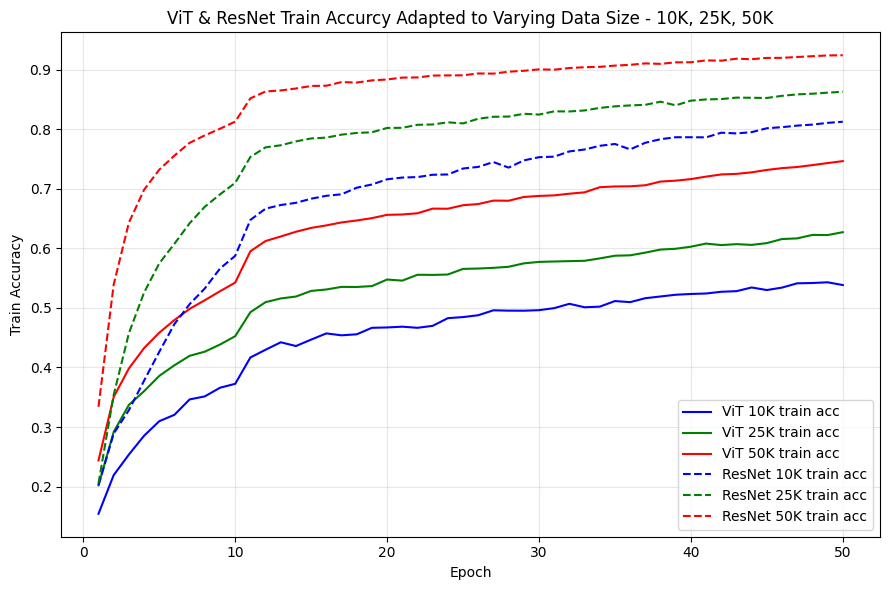

In [ ]:
epochs = range(1, len(ViT_acc_10K) + 1)

plt.figure(figsize=(9, 6))

# ViT: solid
plt.plot(epochs, ViT_acc_10K, "b-", label="ViT 10K train acc")
plt.plot(epochs, ViT_acc_25K, "g-", label="ViT 25K train acc")
plt.plot(epochs, ViT_acc_50K, "r-", label="ViT 50K train acc")

# ResNet: dot
plt.plot(epochs, Res_acc_10K, "b--", label="ResNet 10K train acc")
plt.plot(epochs, Res_acc_25K, "g--", label="ResNet 25K train acc")
plt.plot(epochs, Res_acc_50K, "r--", label="ResNet 50K train acc")

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy")
plt.title("ViT & ResNet Train Accurcy Adapted to Varying Data Size - 10K, 25K, 50K")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('vit_res_train_acc.png', dpi=300, bbox_inches='tight')
plt.show()

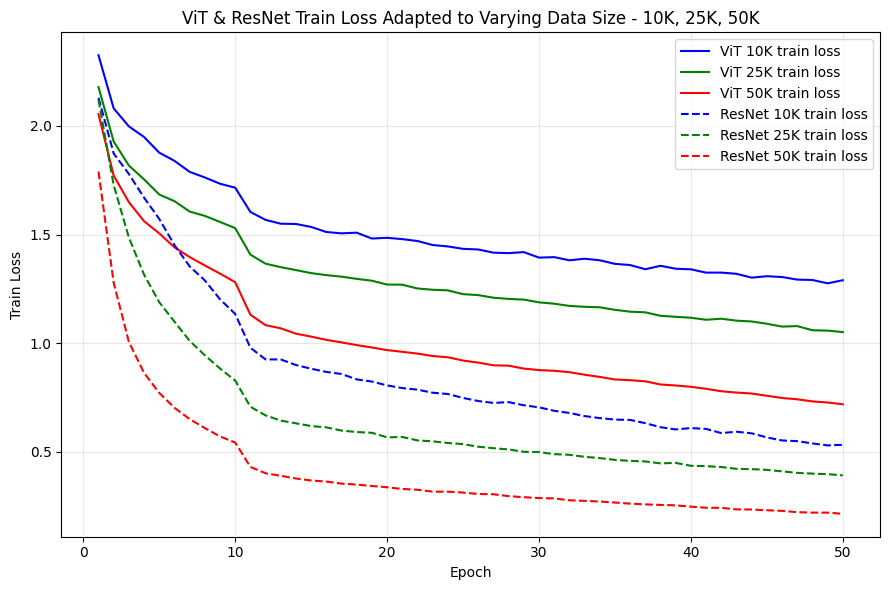

In [ ]:
epochs = range(1, len(ViT_loss_10K) + 1)

plt.figure(figsize=(9, 6))

# ViT: solid
plt.plot(epochs, ViT_loss_10K, "b-", label="ViT 10K train loss")
plt.plot(epochs, ViT_loss_25K, "g-", label="ViT 25K train loss")
plt.plot(epochs, ViT_loss_50K, "r-", label="ViT 50K train loss")

# ResNet: dot
plt.plot(epochs, Res_loss_10K, "b--", label="ResNet 10K train loss")
plt.plot(epochs, Res_loss_25K, "g--", label="ResNet 25K train loss")
plt.plot(epochs, Res_loss_50K, "r--", label="ResNet 50K train loss")

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("ViT & ResNet Train Loss Adapted to Varying Data Size - 10K, 25K, 50K")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('vit_res_train_loss.png', dpi=300, bbox_inches='tight')
plt.show()

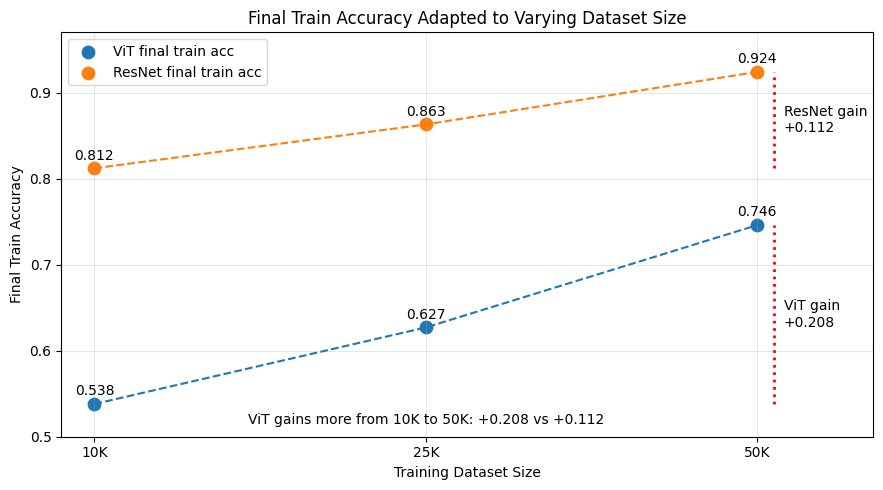

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# x-axis labels
dataset_sizes = ["10K", "25K", "50K"]
x = np.arange(len(dataset_sizes))

# Use final epoch accuracy
# Replace these variable names with your actual train accuracy lists
vit_final_acc = [
    ViT_acc_10K[-1],
    ViT_acc_25K[-1],
    ViT_acc_50K[-1],
]

res_final_acc = [
    Res_acc_10K[-1],
    Res_acc_25K[-1],
    Res_acc_50K[-1],
]

import matplotlib.pyplot as plt
import numpy as np

dataset_sizes = ["10K", "25K", "50K"]
x = np.arange(len(dataset_sizes))

vit_final_acc = [0.538, 0.627, 0.746]
res_final_acc = [0.812, 0.863, 0.924]

vit_gap = vit_final_acc[-1] - vit_final_acc[0]
res_gap = res_final_acc[-1] - res_final_acc[0]

plt.figure(figsize=(9, 5))

plt.scatter(x, vit_final_acc, s=80, label="ViT final train acc")
plt.plot(x, vit_final_acc, linestyle="--")

plt.scatter(x, res_final_acc, s=80, label="ResNet final train acc")
plt.plot(x, res_final_acc, linestyle="--")

# Point labels
for i, acc in enumerate(vit_final_acc):
    plt.text(x[i], acc + 0.01, f"{acc:.3f}", ha="center")

for i, acc in enumerate(res_final_acc):
    plt.text(x[i], acc + 0.01, f"{acc:.3f}", ha="center")

# Gap visualization
vit_gap_x = 2.05
res_gap_x = 2.05

plt.vlines(
    x=vit_gap_x,
    ymin=vit_final_acc[0],
    ymax=vit_final_acc[-1],
    color = 'r',
    linestyles="dotted",
    linewidth=2,
)

plt.text(
    vit_gap_x + 0.03,
    (vit_final_acc[0] + vit_final_acc[-1]) / 2,
    f"ViT gain\n+{vit_gap:.3f}",
    va="center",
)

plt.vlines(
    x=res_gap_x,
    ymin=res_final_acc[0],
    ymax=res_final_acc[-1],
    color = 'r',
    linestyles="dotted",
    linewidth=2,
)

plt.text(
    res_gap_x + 0.03,
    (res_final_acc[0] + res_final_acc[-1]) / 2,
    f"ResNet gain\n+{res_gap:.3f}",
    va="center",
)

plt.text(
    1.0,
    0.515,
    f"ViT gains more from 10K to 50K: +{vit_gap:.3f} vs +{res_gap:.3f}",
    ha="center",
    fontsize=10,
)

plt.xticks(x, dataset_sizes)
plt.xlabel("Training Dataset Size")
plt.ylabel("Final Train Accuracy")
plt.title("Final Train Accuracy Adapted to Varying Dataset Size")
plt.ylim(0.5, 0.97)
plt.xlim(-0.1, 2.35)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

##Experiment 2: Knowledge Distillation (DeiT)

In [ ]:
class DeiT(nn.Module):
  def __init__(self, pt_img_size, img_channel, pt_num_classes, ft_num_classes, patch_size, d_model, num_heads, d_ff, drop_out, L):
    super().__init__()

    self.PatchEmbedding = PatchEmbedding(img_channel, patch_size, d_model)

    self.x_cls = nn.Parameter(torch.randn(1,1,d_model) * math.sqrt(2.0 / d_model)) # He init
    self.x_dist = nn.Parameter(torch.randn(1,1,d_model) * math.sqrt(2.0 / d_model)) # He init

    pt_N = pt_img_size**2 // patch_size**2
    self.pt_PositionalEncoding = nn.Parameter(torch.randn(1,pt_N+2, d_model) * math.sqrt(2.0 / d_model)) # He init

    self.Encoder = Encoder(d_model, num_heads, d_ff, drop_out, L)

    self.pt_cls_MLPHead = nn.Linear(d_model, pt_num_classes) # Seperate heads
    self.pt_dist_MLPHead = nn.Linear(d_model, pt_num_classes) # Seperate heads
    self.ft_MLPHead = nn.Linear(d_model, ft_num_classes)


  def forward(self, x):
    B = x.size(0)

    x = self.PatchEmbedding(x) # (B,N,d_model)
    x = torch.cat((self.x_cls.expand(B,1,-1), self.x_dist.expand(B,1,-1), x), dim=1) # (B,N+1,d_model)
    x = self.pt_PositionalEncoding + x

    x = self.Encoder(x)

    x_cls = x[:,0,:]
    x_dist = x[:,1,:]

    x_cls = self.pt_cls_MLPHead(x_cls)
    x_dist = self.pt_dist_MLPHead(x_dist)

    return (x_cls, x_dist)

In [ ]:
model_ResNet74 = ResNet(N=12).to(device) # ResNet74
model_ViT = VisionTransformer(pt_img_size=32, img_channel=3, pt_num_classes=10, ft_num_classes=10, patch_size=4, d_model=128, num_heads=4, d_ff=512, drop_out=0.1, L=6).to(device)
model_DeiT = DeiT(pt_img_size=32, img_channel=3, pt_num_classes=10, ft_num_classes=10, patch_size=4, d_model=128, num_heads=4, d_ff=512, drop_out=0.1, L=6).to(device)

In [ ]:
# ResNet

model = model_ResNet74
model.train()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)
scheduler_linear = torch.optim.lr_scheduler.LinearLR(optimizer=optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
scheduler_cos = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=35, eta_min=1e-5)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer=optimizer, schedulers=[scheduler_linear,scheduler_cos], milestones=[5])

epochs = 40
for epoch in range(epochs):
    epoch_loss = 0
    epoch_acc = 0

    for batch, (x_train,y_train) in enumerate(train_dataloader_50K):
      x_train, y_train = x_train.to(device), y_train.to(device)

      logits = model(x_train)

      optimizer.zero_grad()
      loss = loss_fn(logits, y_train)
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()

    scheduler.step()
    print(f"epoch {epoch+1} loss: {epoch_loss / len(train_dataloader_50K)}")

In [ ]:
# ViT

model = model_ViT
model.train()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
scheduler_linear = torch.optim.lr_scheduler.LinearLR(optimizer=optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
scheduler_cos = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=35, eta_min=1e-5)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer=optimizer, schedulers=[scheduler_linear,scheduler_cos], milestones=[5])

epochs = 40
for epoch in range(epochs):
    epoch_loss = 0
    epoch_acc = 0

    for batch, (x_train,y_train) in enumerate(train_dataloader_50K):
      x_train, y_train = x_train.to(device), y_train.to(device)

      logits = model(x_train)

      optimizer.zero_grad()
      loss = loss_fn(logits, y_train)
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()

    scheduler.step()
    print(f"epoch {epoch+1} loss: {epoch_loss / len(train_dataloader_50K)}")

In [ ]:
# DeiT Knowledge Distillation

model = model_DeiT
teacher = model_ResNet74
model.train()
teacher.eval()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
scheduler_linear = torch.optim.lr_scheduler.LinearLR(optimizer=optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
scheduler_cos = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=35, eta_min=1e-5)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer=optimizer, schedulers=[scheduler_linear,scheduler_cos], milestones=[5])

epochs = 40
for epoch in range(epochs):
    epoch_loss = 0
    epoch_acc = 0

    for batch, (x_train,y_train) in enumerate(train_dataloader_50K):
      x_train, y_train = x_train.to(device), y_train.to(device)

      x_cls_logits, x_dist_logits = model(x_train)
      with torch.no_grad():
        teacher_logits = teacher(x_train).argmax(dim=-1)

      optimizer.zero_grad()
      loss = 0.5 * loss_fn(x_cls_logits, y_train) + 0.5 * loss_fn(x_dist_logits, teacher_logits)
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()

    scheduler.step()
    print(f"epoch {epoch+1} loss: {epoch_loss / len(train_dataloader_50K)}")

In [ ]:
with torch.no_grad():
  model_ResNet74.eval()
  res_epoch_acc = 0

  for batch, (x_test,y_test) in enumerate(test_dataloader):
    x_test, y_test = x_test.to(device), y_test.to(device)
    res_logits = model_ResNet74(x_test)
    res_epoch_acc += sum(res_logits.argmax(dim=-1) == y_test)

  print(f"ResNet74 test acc: {res_epoch_acc / len(test_dataset)}")

ResNet74 test acc: 0.9145999550819397


In [ ]:
with torch.no_grad():
  model_ViT.eval()
  vit_epoch_acc = 0

  for batch, (x_test,y_test) in enumerate(test_dataloader):
    x_test, y_test = x_test.to(device), y_test.to(device)
    vit_logits = model_ViT(x_test)
    vit_epoch_acc += sum(vit_logits.argmax(dim=-1) == y_test)

  print(f"ViT test acc: {vit_epoch_acc / len(test_dataset)}")

ViT test acc: 0.8012999892234802


In [ ]:
with torch.no_grad():
  model_DeiT.eval()
  deit_epoch_acc = 0
  cls_epoch_acc = 0
  dist_epoch_acc = 0

  softmax = nn.functional.softmax

  for batch, (x_test,y_test) in enumerate(test_dataloader):
    x_test, y_test = x_test.to(device), y_test.to(device)

    x_cls_logits, x_dist_logits = model_DeiT(x_test)

    deit_epoch_acc += sum((softmax(x_cls_logits, dim=-1) + softmax(x_dist_logits, dim=-1)).argmax(dim=-1) == y_test) # late fusion
    cls_epoch_acc += sum(x_cls_logits.argmax(dim=-1) == y_test)
    dist_epoch_acc += sum(x_dist_logits.argmax(dim=-1) == y_test)

  print(f"DeiT test acc: {deit_epoch_acc / len(test_dataset)}")
  print(f"CLS Token test acc: {cls_epoch_acc / len(test_dataset)}")
  print(f"DIST Token test acc: {dist_epoch_acc / len(test_dataset)}")

DeiT test acc: 0.8037999868392944
CLS Token test acc: 0.8023999929428101
DIST Token test acc: 0.8032999634742737
